In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score
import sys

sys.executable
sys.version

'3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]'

In [26]:
df = pd.read_csv('../data/raw/instagram_usage_lifestyle.csv')
type (df)
pd.core.frame.DataFrame
df


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,1547892,Instagram,61,Female,United States,Suburban,High,Full-time employed,Master’s,Widowed,...,2025-01-14,15.8,Videos,Other,Friends only,Yes,Yes,4,Free,0.97
1547892,1547893,Instagram,42,Male,United States,Urban,Lower-middle,Full-time employed,Master’s,Divorced,...,2025-08-04,38.0,Photos,Art,Private,No,No,1,Premium,1.32
1547893,1547894,Instagram,32,Male,Canada,Urban,Low,Full-time employed,Master’s,Single,...,2025-04-10,31.8,Live,Other,Private,Yes,Yes,5,Free,1.01
1547894,1547895,Instagram,14,Female,Other,Urban,Low,Student,Bachelor’s,Single,...,2025-03-21,23.6,Live,Tech,Private,Yes,No,3,Free,1.11


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

In [28]:
print(df.shape)
print(df.head())
print(df.info())

(1547896, 58)
   user_id   app_name  age      gender         country urban_rural  \
0        1  Instagram   51      Female           India       Rural   
1        2  Instagram   64      Female  United Kingdom       Urban   
2        3  Instagram   41      Female          Canada       Urban   
3        4  Instagram   27  Non-binary     South Korea       Urban   
4        5  Instagram   55        Male           India       Urban   

   income_level   employment_status education_level relationship_status  ...  \
0          High             Retired      Bachelor’s              Single  ...   
1        Middle  Full-time employed           Other            Divorced  ...   
2        Middle             Student      Bachelor’s   In a relationship  ...   
3        Middle          Unemployed        Master’s   In a relationship  ...   
4  Upper-middle  Full-time employed      Bachelor’s              Single  ...   

  last_login_date  average_session_length_minutes  content_type_preference  \
0     

In [29]:
df.isnull().sum().sort_values(ascending=False)

user_id                           0
app_name                          0
age                               0
gender                            0
country                           0
urban_rural                       0
income_level                      0
employment_status                 0
education_level                   0
relationship_status               0
has_children                      0
exercise_hours_per_week           0
sleep_hours_per_night             0
diet_quality                      0
smoking                           0
alcohol_frequency                 0
perceived_stress_score            0
self_reported_happiness           0
body_mass_index                   0
blood_pressure_systolic           0
blood_pressure_diastolic          0
daily_steps_count                 0
weekly_work_hours                 0
hobbies_count                     0
social_events_per_month           0
books_read_per_year               0
volunteer_hours_per_month         0
travel_frequency_per_year   

In [30]:
df["income_level"].value_counts()

income_level
Middle          465037
Lower-middle    386815
Low             309736
Upper-middle    231747
High            154561
Name: count, dtype: int64

In [31]:
df["income_level"].value_counts(normalize=True) * 100

income_level
Middle          30.043168
Lower-middle    24.989728
Low             20.010130
Upper-middle    14.971742
High             9.985232
Name: proportion, dtype: float64

In [32]:
df["gender"].value_counts()

gender
Male                 743169
Female               742847
Non-binary            46196
Prefer not to say     15684
Name: count, dtype: int64

In [33]:
df_work = df.copy()

df_work = pd.get_dummies(df_work, columns=["gender"], drop_first=True)

X_cols = [
    "age",
    "sessions_per_day","posts_created_per_week","reels_watched_per_day",
    "stories_viewed_per_day","likes_given_per_day","comments_written_per_day",
    "dms_sent_per_week","dms_received_per_week",
    "time_on_messages_per_day","time_on_reels_per_day",
    "daily_active_minutes_instagram","average_session_length_minutes",
    "followers_count","following_count","user_engagement_score"
] + [c for c in df_work.columns if c.startswith("gender_")]

X = df_work[X_cols]
X

,age,sessions_per_day,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,time_on_messages_per_day,time_on_reels_per_day,daily_active_minutes_instagram,average_session_length_minutes,followers_count,following_count,user_engagement_score,gender_Male,gender_Non-binary,gender_Prefer not to say
0,51,1,3,42,28,28,5,12,12,1,2,5.0,5.0,374,647,7.83,False,False,False
1,64,5,3,78,54,68,15,18,10,16,19,74.0,14.8,2585,3511,1.43,False,False,False
2,41,1,7,29,26,25,6,12,13,1,1,5.0,5.0,3414,6761,9.67,False,False,False
3,27,9,5,241,109,132,36,31,32,52,64,233.0,25.9,617,1193,0.94,False,True,False
4,55,14,5,146,113,103,36,29,37,22,55,184.0,13.1,1157,1072,1.03,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,61,12,6,156,111,125,21,35,26,33,65,190.0,15.8,1265,1012,0.97,False,False,False
1547892,42,2,6,88,61,60,12,11,20,11,26,76.0,38.0,1312,1348,1.32,True,False,False
1547893,32,5,4,156,91,92,29,29,23,33,48,159.0,31.8,1968,1891,1.01,True,False,False
1547894,14,12,13,280,149,179,48,51,33,30,107,283.0,23.6,3932,4775,1.11,False,False,False


In [34]:
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=0.9, random_state=42).fit_transform(X_scaled)

X_pca.shape


(1547896, 8)

In [35]:
df_k = df_work.sample(n=10_000, random_state=42)
X_k = df_k[X_cols]

In [36]:
X_scaled = StandardScaler().fit_transform(X_k)

pca2 = PCA(n_components=2, random_state=42)
X_pca_2d = pca2.fit_transform(X_scaled)

pca3 = PCA(n_components=3, random_state=42)
X_pca_3d = pca3.fit_transform(X_scaled)

In [37]:
k = 4  # initial value
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_pca_2d)

sil = silhouette_score(X_pca_2d, labels)
sil

0.4250742118366499

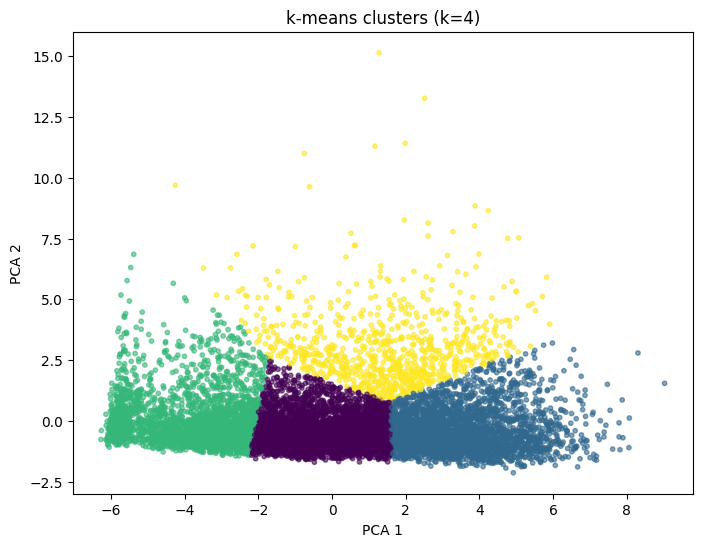

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels,
    s=10,
    alpha=0.6
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"k-means clusters (k={k})")
plt.show()

In [58]:
k = 4
labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_pca_3d)

sil = silhouette_score(X_pca_3d, labels)
sil

0.3111857924708439

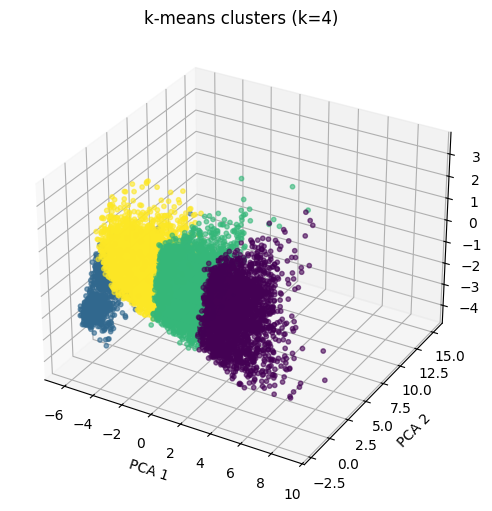

In [40]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=labels,
    s=10,
    alpha=0.6
)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title(f"k-means clusters (k={k})")

plt.show()

In [41]:
df_k["cluster"] = labels

(
    df_k
    .groupby("cluster")["income_level"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
)


,cluster,income_level,share
0,0,Middle,0.296207
1,0,Lower-middle,0.255448
2,0,Low,0.203793
3,0,Upper-middle,0.142857
4,0,High,0.101695
5,1,Middle,0.306843
6,1,Lower-middle,0.245033
7,1,Low,0.200883
8,1,Upper-middle,0.150110
9,1,High,0.097130


In [44]:
X2_cols = [
    "sessions_per_day","posts_created_per_week","reels_watched_per_day",
    "stories_viewed_per_day","likes_given_per_day","comments_written_per_day",
    "dms_sent_per_week","dms_received_per_week",
    "time_on_messages_per_day","time_on_reels_per_day",
    "daily_active_minutes_instagram","average_session_length_minutes",
    "followers_count","following_count","user_engagement_score"
]

X2 = df_k[X2_cols]

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X2_scaled = StandardScaler().fit_transform(X2)
pca = PCA(n_components=3, random_state=42)
X2_pca = pca.fit_transform(X2_scaled)


In [45]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X2_cols,
    columns=["PCA1", "PCA2", "PCA3"]
)

loadings.sort_values("PCA1", ascending=False)

,PCA1,PCA2,PCA3
daily_active_minutes_instagram,0.325890,-0.027011,-0.005670
likes_given_per_day,0.320376,-0.026505,-0.005122
stories_viewed_per_day,0.316252,-0.018975,0.020532
comments_written_per_day,0.310626,-0.024572,-0.004491
time_on_reels_per_day,0.308636,-0.025595,-0.009595
dms_received_per_week,0.305745,-0.024726,-0.002675
time_on_messages_per_day,0.299170,-0.028787,-0.003372
dms_sent_per_week,0.299078,-0.023016,-0.006889
reels_watched_per_day,0.296949,0.024168,-0.001495
sessions_per_day,0.250507,-0.031628,-0.431683


In [ ]:
X2_pca_2d = pca2.fit_transform(X_scaled)
X2_pca_3d = pca3.fit_transform(X_scaled)

sil = silhouette_score(X2_pca_3d, labels)
sil

0.3111857924708439

In [60]:
labels = kmeans.fit_predict(X2_pca_2d)
sil = silhouette_score(X2_pca_2d, labels)
sil

0.4250742118366499

In [61]:
labels = kmeans.fit_predict(X2_pca_3d)
sil = silhouette_score(X2_pca_3d, labels)
sil

0.3111857924708439

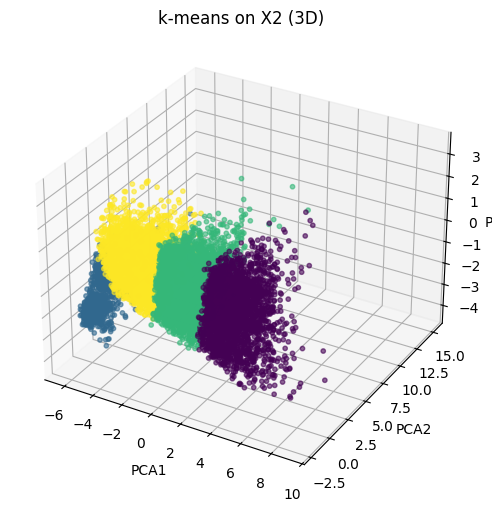

In [65]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X2_pca_3d[:, 0],
    X2_pca_3d[:, 1],
    X2_pca_3d[:, 2],
    c=labels,
    s=10,
    alpha=0.6
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("k-means on X2 (3D)")
plt.show()

In [66]:
scores = {}

for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42)\
        .fit_predict(X2_pca_2d)
    scores[k] = silhouette_score(X2_pca_2d, labels)

scores

{2: 0.4949596853151602,
 3: 0.4025670063222412,
 4: 0.4250742118366499,
 5: 0.39661222114432926,
 6: 0.41332627187927573,
 7: 0.3808463506303905,
 8: 0.359133695418383}

In [67]:
labels_2d = kmeans.fit_predict(X2_pca_2d)
df_k["cluster"] = labels_2d

df_k.groupby("cluster")[[
    "posts_created_per_week",
    "comments_written_per_day",
    "likes_given_per_day",
    "stories_viewed_per_day",
    "reels_watched_per_day"
]].mean()


,posts_created_per_week,comments_written_per_day,likes_given_per_day,stories_viewed_per_day,reels_watched_per_day
cluster,,,,,
0,5.046602,32.215534,112.561997,99.760610,168.115673
1,8.710781,53.579129,183.719765,143.680028,255.512785
2,3.527007,13.867967,51.367592,51.247187,87.043886
3,9.004790,40.137725,139.120958,119.780838,218.844311
